# 🏀 NBA Salary Predictor — Previsão de Salários da NBA

## Problema de Negócio
Com base nas estatísticas de desempenho da temporada 2022-23, este modelo
prevê o salário anual de um jogador da NBA.

Isso é útil para:
- Times que precisam tomar decisões estratégicas de contratação
- Agentes esportivos que negociam contratos com base em desempenho real
- Análise de jogadores sub ou supervalorizados no mercado

## Variável Alvo
`Salary` — salário anual do jogador em dólares (valor numérico contínuo)

## Dataset
NBA Players Stats and Salaries — Temporada 2022-23
- 467 registros
- 52 colunas
- Fonte: Kaggle

In [2]:
# ============================================================
# NBA Salary Predictor
# Célula 1: Importação das bibliotecas
# ============================================================

# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Versionamento do modelo
import joblib
import json
import os
from datetime import datetime

# Configurações visuais
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)

# Ignorar warnings desnecessários
import warnings
warnings.filterwarnings("ignore")

print("✅ Bibliotecas importadas com sucesso!")

✅ Bibliotecas importadas com sucesso!


In [3]:
# ============================================================
# Célula 2: Fase 1 — Carregar o Dataset
# ============================================================

# Carregando o dataset do NBA 2022-23
df = pd.read_csv("nba_2022-23_all_stats_with_salary.csv")

print(f"✅ Dataset carregado com sucesso!")
print(f"   Linhas    : {df.shape[0]}")
print(f"   Colunas   : {df.shape[1]}")
print(f"\n📋 Primeiros registros:")
print(df.head())

✅ Dataset carregado com sucesso!
   Linhas    : 467
   Colunas   : 52

📋 Primeiros registros:
   Unnamed: 0        Player Name    Salary Position  Age     Team  GP  GS  \
0           0      Stephen Curry  48070014       PG   34      GSW  56  56   
1           1          John Wall  47345760       PG   32      LAC  34   3   
2           2  Russell Westbrook  47080179       PG   34  LAL/LAC  73  24   
3           3       LeBron James  44474988       PF   38      LAL  55  54   
4           4       Kevin Durant  44119845       PF   34  BRK/PHO  47  47   

     MP    FG  ...  TOV%  USG%  OWS  DWS   WS  WS/48  OBPM  DBPM  BPM  VORP  
0  34.7  10.0  ...  12.5  31.0  5.8  2.0  7.8  0.192   7.5   0.1  7.5   4.7  
1  22.2   4.1  ...  17.1  27.0 -0.4  0.7  0.3  0.020  -0.8  -0.4 -1.2   0.1  
2  29.1   5.9  ...  18.4  27.7 -0.6  2.6  1.9  0.044   0.3  -0.1  0.2   1.2  
3  35.5  11.1  ...  11.6  33.3  3.2  2.4  5.6  0.138   5.5   0.6  6.1   4.0  
4  35.6  10.3  ...  13.4  30.7  4.7  2.1  6.8  0.194 

In [4]:
# ============================================================
# Célula 3: Fase 1 — Inspeção Inicial do Dataset
# ============================================================

print("=== INFORMAÇÕES GERAIS DO DATASET ===")
print("-" * 45)
print(f"  Dimensões        : {df.shape[0]} linhas x {df.shape[1]} colunas")
print(f"  Memória utilizada: {df.memory_usage().sum() / 1024:.2f} KB")
print("-" * 45)

print("\n=== TIPOS DE DADOS POR COLUNA ===")
print("-" * 45)
print(df.dtypes)
print("-" * 45)

print("\n=== VALORES NULOS POR COLUNA ===")
print("-" * 45)
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df)) * 100
nulos_df = pd.DataFrame({
    "Nulos"      : nulos,
    "Percentual" : nulos_pct.round(2)
})
# Mostrar apenas colunas que têm nulos
print(nulos_df[nulos_df["Nulos"] > 0])
print("-" * 45)

print("\n=== ESTATÍSTICAS DESCRITIVAS ===")
print(df.describe().round(2))

=== INFORMAÇÕES GERAIS DO DATASET ===
---------------------------------------------
  Dimensões        : 467 linhas x 52 colunas
  Memória utilizada: 189.85 KB
---------------------------------------------

=== TIPOS DE DADOS POR COLUNA ===
---------------------------------------------
Unnamed: 0         int64
Player Name       object
Salary             int64
Position          object
Age                int64
Team              object
GP                 int64
GS                 int64
MP               float64
FG               float64
FGA              float64
FG%              float64
3P               float64
3PA              float64
3P%              float64
2P               float64
2PA              float64
2P%              float64
eFG%             float64
FT               float64
FTA              float64
FT%              float64
ORB              float64
DRB              float64
TRB              float64
AST              float64
STL              float64
BLK              float64
TOV          

## Fase 1: Análise Exploratória de Dados (EDA)

Nesta fase analisamos visualmente o dataset para entender:
- A distribuição da variável alvo (Salary)
- A relação entre as variáveis explicativas e o salário
- A correlação entre as variáveis numéricas

Esses achados orientarão nossas decisões de limpeza e modelagem.

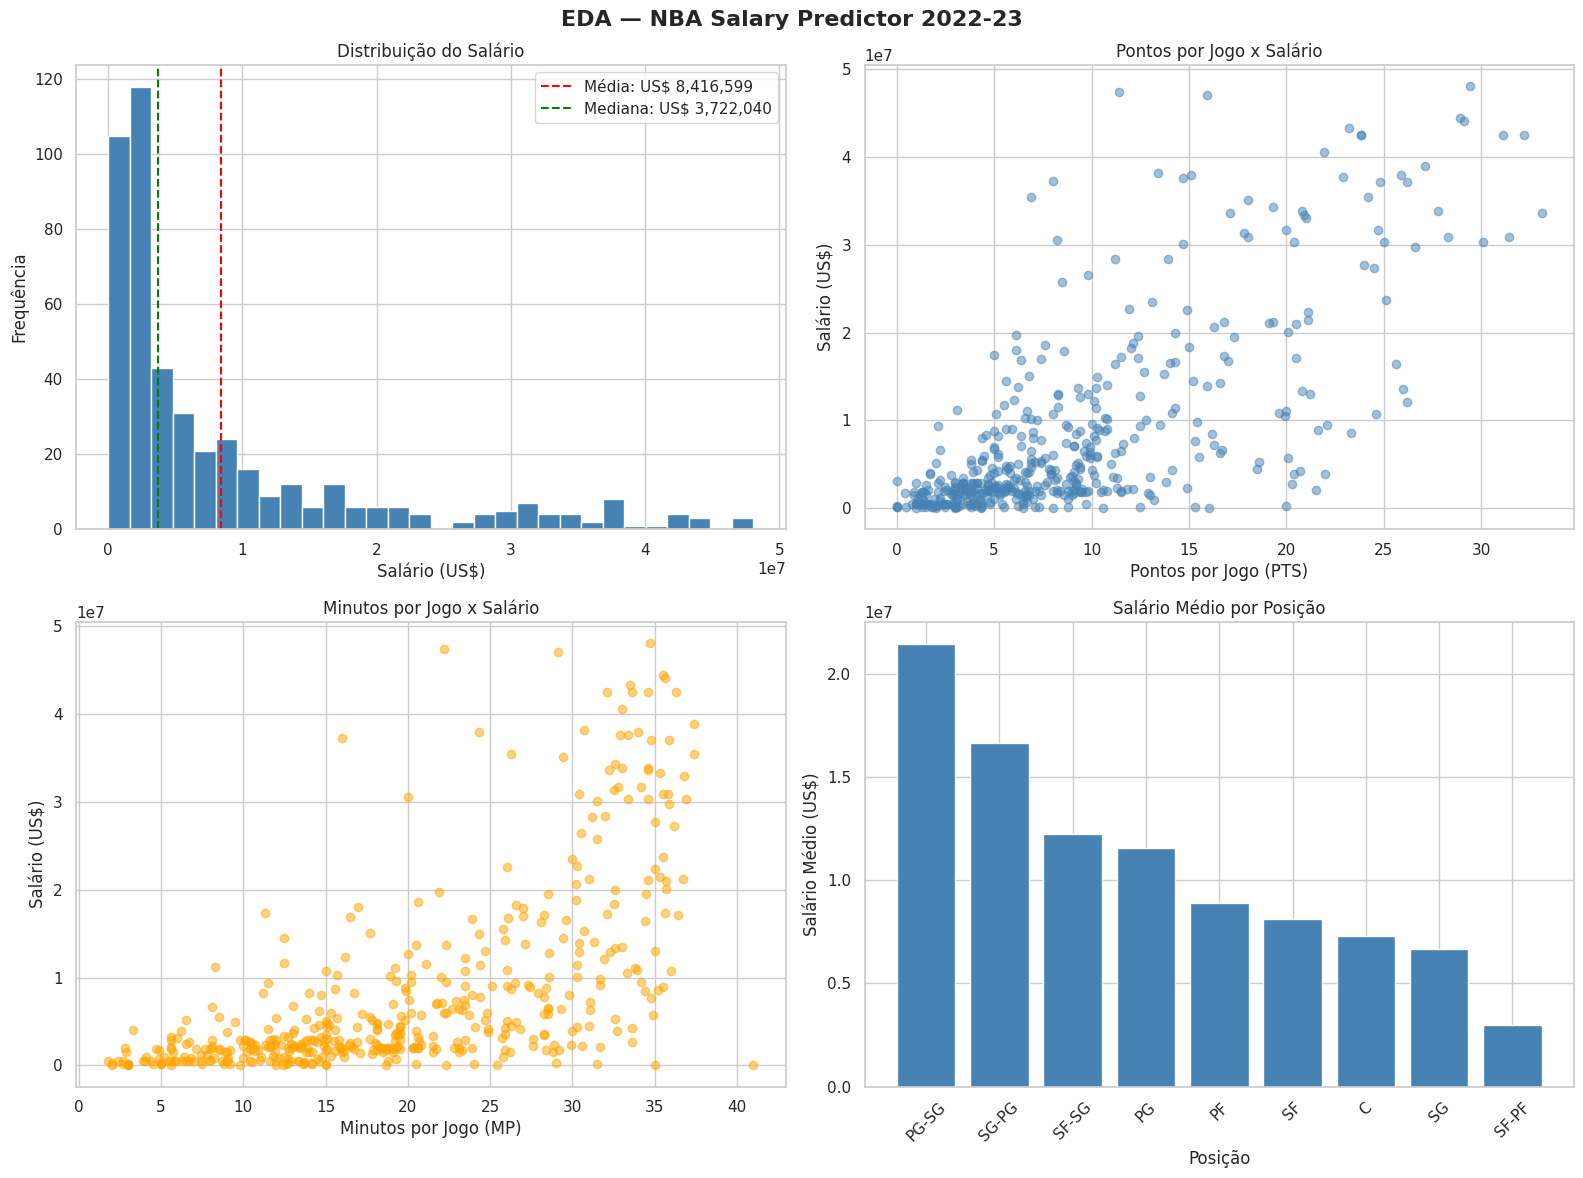

✅ Gráficos EDA gerados!


In [5]:
# ============================================================
# Célula 4: Fase 1 — Visualizações EDA
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("EDA — NBA Salary Predictor 2022-23", fontsize=16, fontweight="bold")

# --------------------------------------------------------
# Gráfico 1: Distribuição do Salário (variável alvo)
# Mostra se a distribuição é simétrica ou assimétrica
# --------------------------------------------------------
axes[0, 0].hist(df["Salary"], bins=30, color="steelblue", edgecolor="white")
axes[0, 0].set_title("Distribuição do Salário")
axes[0, 0].set_xlabel("Salário (US$)")
axes[0, 0].set_ylabel("Frequência")
axes[0, 0].axvline(df["Salary"].mean(), color="red", linestyle="--", label=f'Média: US$ {df["Salary"].mean():,.0f}')
axes[0, 0].axvline(df["Salary"].median(), color="green", linestyle="--", label=f'Mediana: US$ {df["Salary"].median():,.0f}')
axes[0, 0].legend()

# --------------------------------------------------------
# Gráfico 2: Dispersão PTS x Salary
# Mostra se jogadores que pontuam mais ganham mais
# --------------------------------------------------------
axes[0, 1].scatter(df["PTS"], df["Salary"], alpha=0.5, color="steelblue")
axes[0, 1].set_title("Pontos por Jogo x Salário")
axes[0, 1].set_xlabel("Pontos por Jogo (PTS)")
axes[0, 1].set_ylabel("Salário (US$)")

# --------------------------------------------------------
# Gráfico 3: Dispersão MP x Salary
# Mostra se jogadores que jogam mais minutos ganham mais
# --------------------------------------------------------
axes[1, 0].scatter(df["MP"], df["Salary"], alpha=0.5, color="orange")
axes[1, 0].set_title("Minutos por Jogo x Salário")
axes[1, 0].set_xlabel("Minutos por Jogo (MP)")
axes[1, 0].set_ylabel("Salário (US$)")

# --------------------------------------------------------
# Gráfico 4: Salário médio por posição
# Mostra qual posição tem maior remuneração
# --------------------------------------------------------
salary_position = df.groupby("Position")["Salary"].mean().sort_values(ascending=False)
axes[1, 1].bar(salary_position.index, salary_position.values, color="steelblue", edgecolor="white")
axes[1, 1].set_title("Salário Médio por Posição")
axes[1, 1].set_xlabel("Posição")
axes[1, 1].set_ylabel("Salário Médio (US$)")
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("grafico_eda.png", dpi=120)
plt.show()
plt.close()
print("✅ Gráficos EDA gerados!")

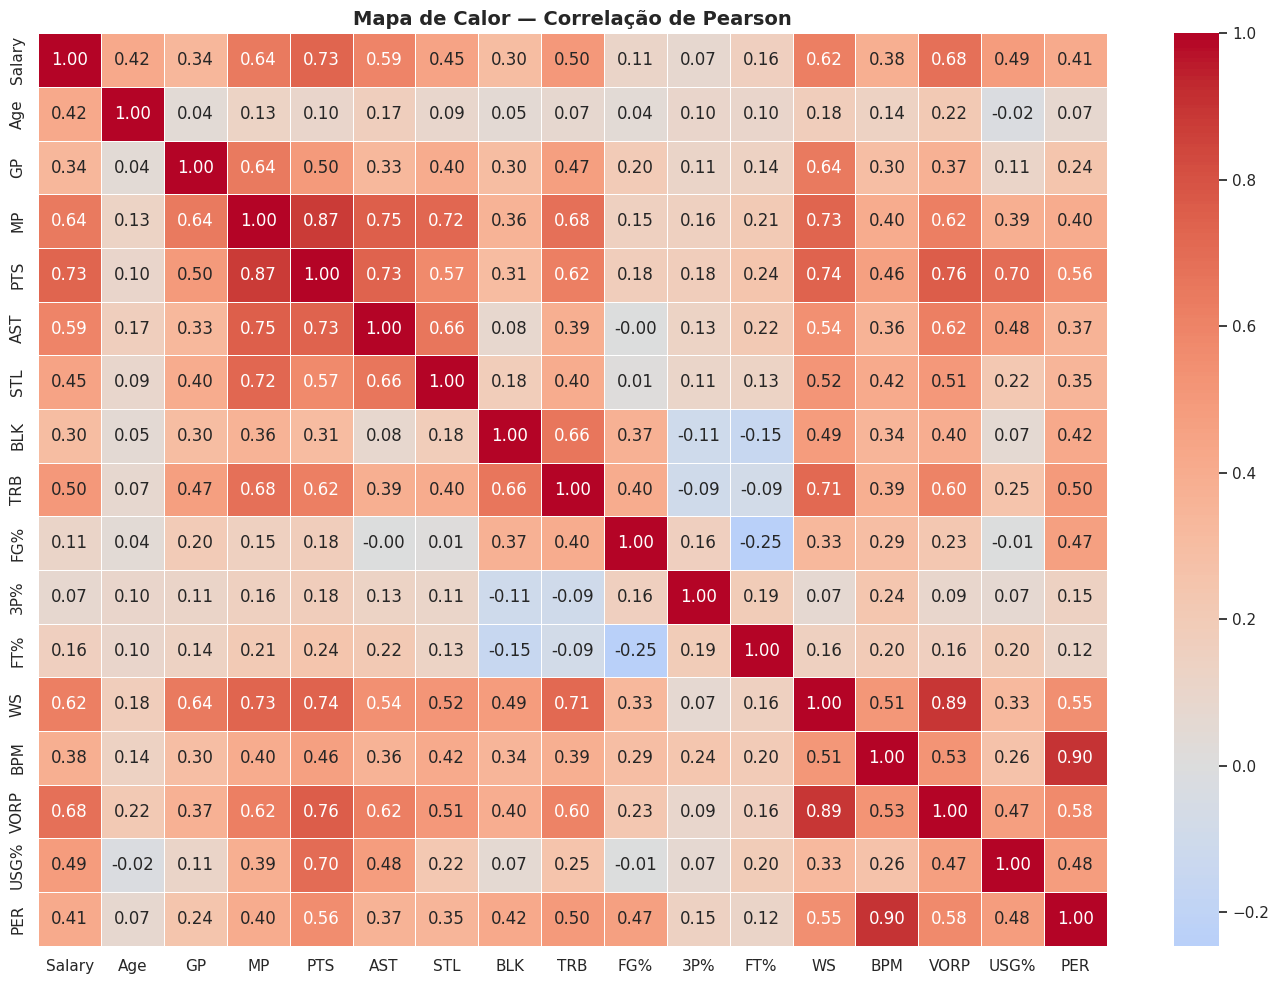

✅ Mapa de calor gerado!


In [6]:
# ============================================================
# Célula 5: Fase 1 — Mapa de Calor de Correlação
# ============================================================

# Selecionando as colunas mais relevantes para análise
# Evitamos colunas redundantes e focamos nas principais métricas
colunas_relevantes = [
    "Salary", "Age", "GP", "MP", "PTS", "AST",
    "STL", "BLK", "TRB", "FG%", "3P%", "FT%",
    "WS", "BPM", "VORP", "USG%", "PER"
]

# Calculando a correlação de Pearson entre as variáveis
correlacao = df[colunas_relevantes].corr()

# Plotando o mapa de calor
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(
    correlacao,
    annot=True,          # mostra os valores dentro das células
    fmt=".2f",           # formato com 2 casas decimais
    cmap="coolwarm",     # azul = correlação negativa, vermelho = positiva
    center=0,            # centro da escala de cores no zero
    linewidths=0.5,      # linhas entre as células
    ax=ax
)
ax.set_title("Mapa de Calor — Correlação de Pearson", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("grafico_correlacao.png", dpi=120)
plt.show()
plt.close()
print("✅ Mapa de calor gerado!")

## Análise Textual — Achados da EDA

### Distribuição da variável alvo (Salary)
O salário apresenta distribuição fortemente assimétrica à direita,
com a maioria dos jogadores ganhando entre US$ 1M e US$ 5M e poucos
jogadores com salários acima de US$ 30M. A média (US$ 8,4M) está bem
acima da mediana (US$ 3,7M), confirmando a assimetria. Isso indica
que usaremos a **mediana** como estratégia de imputação de valores
ausentes nas etapas seguintes.

### Variáveis mais relevantes
As variáveis com maior correlação com o salário são PTS (0.73),
VORP (0.68), MP (0.64) e WS (0.62), indicando que jogadores que
pontuam mais, jogam mais minutos e contribuem mais para as vitórias
tendem a ser mais bem remunerados.

### Multicolinearidade
Detectamos alta correlação entre MP e PTS (0.87), WS e VORP (0.89)
e BPM e PER (0.90). Na Fase 4 avaliaremos quais variáveis remover
para evitar que a multicolinearidade distorça o modelo de regressão.

### Posições
O dataset apresenta posições combinadas como PG-SG e SF-SG que
precisarão ser simplificadas na Fase 2.

### Orientação para modelagem
Dado o perfil assimétrico do salário, consideraremos aplicar
transformação logarítmica na variável alvo para melhorar o
desempenho do modelo de regressão linear.

## Fase 2: Tratamento e Limpeza (Data Prep)

Nesta fase tratamos os problemas encontrados na EDA:
- Remoção de colunas desnecessárias
- Simplificação das posições combinadas
- Tratamento de valores ausentes
- Detecção e tratamento de outliers

In [7]:
# ============================================================
# Célula 6: Fase 2 — Limpeza Inicial
# ============================================================

# Criando uma cópia do dataset original para não alterá-lo
df_limpo = df.copy()

# --------------------------------------------------------
# Passo 1: Remover colunas desnecessárias
# --------------------------------------------------------
colunas_remover = [
    # Identificação — não são variáveis preditoras
    "Player Name", "Unnamed: 0",

    # Baixa correlação com salário (abaixo de 0.20)
    "FG%", "3P%", "FT%", "2P%", "eFG%",

    # Tentativas de arremesso — redundantes com as convertidas
    "FGA", "3PA", "FTA", "2PA",

    # Métricas redundantes
    "BPM",          # correlação 0.90 com PER — mantemos PER
    "WS/48",        # versão normalizada de WS — mantemos WS
    "OBPM",         # componente de BPM
    "DBPM",         # componente de BPM
    "ORB",          # componente de TRB — mantemos TRB
    "DRB",          # componente de TRB — mantemos TRB
    "Total Minutes" # redundante com MP * GP
]

df_limpo = df_limpo.drop(columns=colunas_remover)
print(f"✅ {len(colunas_remover)} colunas removidas")
print(f"   Colunas restantes: {len(df_limpo.columns)}")

# --------------------------------------------------------
# Passo 2: Simplificar posições combinadas
# Jogadores com posições como 'PG-SG' serão classificados
# pela primeira posição informada
# --------------------------------------------------------
df_limpo["Position"] = df_limpo["Position"].apply(
    lambda x: x.split("-")[0] if "-" in str(x) else x
)
print(f"\n✅ Posições simplificadas:")
print(df_limpo["Position"].value_counts())

# --------------------------------------------------------
# Passo 3: Verificar e remover duplicatas
# --------------------------------------------------------
n_duplicatas = df_limpo.duplicated().sum()
print(f"\n✅ Duplicatas encontradas: {n_duplicatas}")
if n_duplicatas > 0:
    df_limpo = df_limpo.drop_duplicates()
    print(f"   Duplicatas removidas!")

print(f"\n📊 Shape após limpeza inicial: {df_limpo.shape}")
print(f"\n📋 Colunas mantidas:")
for col in df_limpo.columns:
    print(f"   ✅ {col}")

✅ 18 colunas removidas
   Colunas restantes: 34

✅ Posições simplificadas:
Position
SG    117
SF     94
C      91
PF     86
PG     79
Name: count, dtype: int64

✅ Duplicatas encontradas: 0

📊 Shape após limpeza inicial: (467, 34)

📋 Colunas mantidas:
   ✅ Salary
   ✅ Position
   ✅ Age
   ✅ Team
   ✅ GP
   ✅ GS
   ✅ MP
   ✅ FG
   ✅ 3P
   ✅ 2P
   ✅ FT
   ✅ TRB
   ✅ AST
   ✅ STL
   ✅ BLK
   ✅ TOV
   ✅ PF
   ✅ PTS
   ✅ PER
   ✅ TS%
   ✅ 3PAr
   ✅ FTr
   ✅ ORB%
   ✅ DRB%
   ✅ TRB%
   ✅ AST%
   ✅ STL%
   ✅ BLK%
   ✅ TOV%
   ✅ USG%
   ✅ OWS
   ✅ DWS
   ✅ WS
   ✅ VORP


### Decisões de Limpeza Inicial

**Colunas removidas (18 no total):**
- `Unnamed: 0` e `Player Name`
: não são variáveis preditoras
- `FG%`, `3P%`, `FT%`, `2P%`, `eFG%`: correlação menor que 0.20 com o salário
- `FGA`, `3PA`, `FTA`, `2PA`: tentativas de arremesso, redundantes com as convertidas
- `BPM`, `OBPM`, `DBPM`: redundantes com PER (correlação 0.90)
- `WS/48`: versão normalizada de WS, redundante
- `ORB`, `DRB`: componentes de TRB, redundantes
- `Total Minutes`: redundante com MP × GP

**Posições simplificadas:**
Jogadores com posições combinadas como PG-SG foram classificados
pela primeira posição informada, resultando em 5 posições limpas:
PG, SG, SF, PF e C.

**Duplicatas:**
Nenhuma duplicata encontrada no dataset.



In [8]:
# ============================================================
# Célula 7: Fase 2 — Tratamento de Valores Ausentes
# ============================================================

# Verificando valores ausentes antes do tratamento
print("=== VALORES AUSENTES ANTES DO TRATAMENTO ===")
print("-" * 45)
nulos = df_limpo.isnull().sum()
nulos = nulos[nulos > 0]
for col, n in nulos.items():
    pct = (n / len(df_limpo)) * 100
    print(f"  {col:<10}: {n} nulos ({pct:.1f}%)")
print("-" * 45)

# Imputação pela mediana
# Justificativa: distribuição assimétrica do salário torna
# a mediana mais robusta que a média para imputação
colunas_com_nulos = df_limpo.columns[df_limpo.isnull().any()].tolist()
for col in colunas_com_nulos:
    mediana = df_limpo[col].median()
    df_limpo[col] = df_limpo[col].fillna(mediana)
    print(f"✅ {col:<10}: substituído pela mediana ({mediana:.2f})")

# Verificando após o tratamento
print("\n=== VALORES AUSENTES APÓS O TRATAMENTO ===")
print("-" * 45)
nulos_depois = df_limpo.isnull().sum().sum()
print(f"  Total de nulos restantes: {nulos_depois}")
print("-" * 45)

=== VALORES AUSENTES ANTES DO TRATAMENTO ===
---------------------------------------------
  TS%       : 1 nulos (0.2%)
  3PAr      : 1 nulos (0.2%)
  FTr       : 1 nulos (0.2%)
---------------------------------------------
✅ TS%       : substituído pela mediana (0.57)
✅ 3PAr      : substituído pela mediana (0.41)
✅ FTr       : substituído pela mediana (0.23)

=== VALORES AUSENTES APÓS O TRATAMENTO ===
---------------------------------------------
  Total de nulos restantes: 0
---------------------------------------------


### Tratamento de Outliers

Detectamos outliers nas variáveis numéricas usando boxplots.
Para o salário especificamente, optamos por MANTER os outliers
pois superestrelas como LeBron James e Stephen Curry representam
casos reais e legítimos do mercado da NBA — removê-los distorceria
a análise de negócio.

Para as variáveis explicativas, aplicamos contenção por limite
(winsorização) nas colunas com outliers extremos, substituindo
valores fora dos limites pelo valor do limite mais próximo.

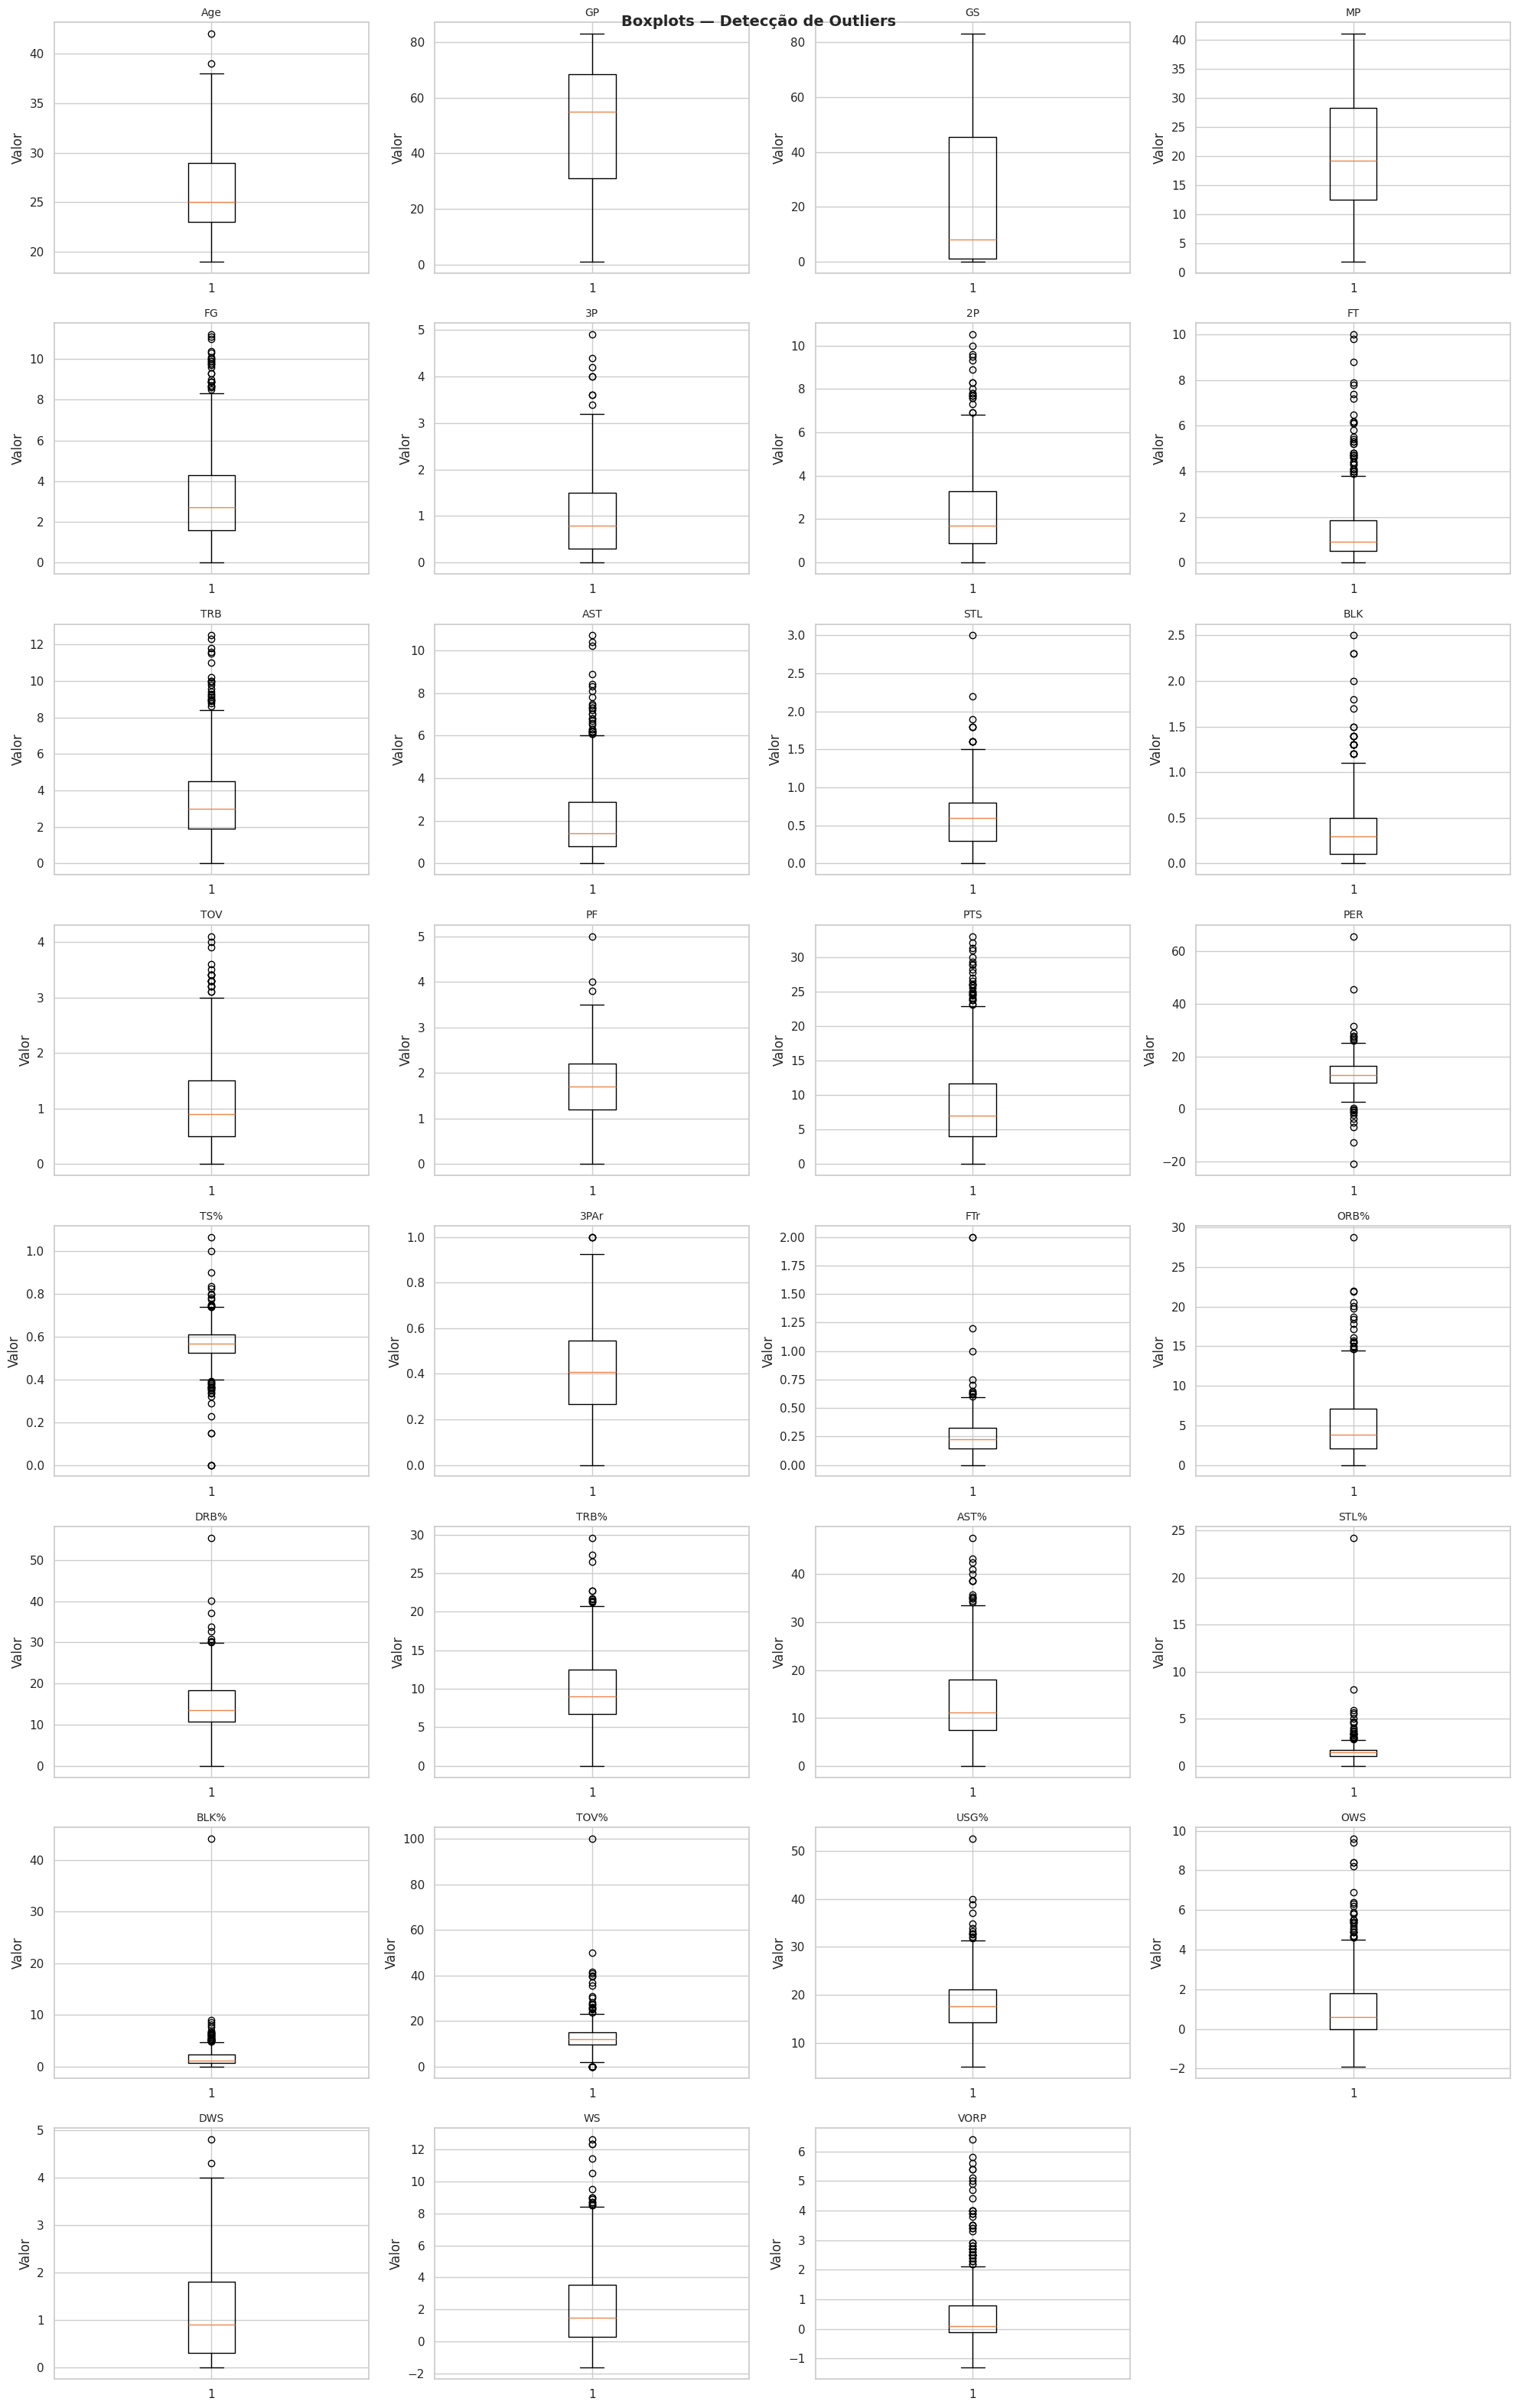

✅ Boxplots gerados!

=== OUTLIERS TRATADOS POR WINSORIZAÇÃO ===
---------------------------------------------
  Age         : 2 outliers contidos
  FG          : 26 outliers contidos
  3P          : 8 outliers contidos
  2P          : 19 outliers contidos
  FT          : 41 outliers contidos
  TRB         : 22 outliers contidos
  AST         : 30 outliers contidos
  STL         : 10 outliers contidos
  BLK         : 22 outliers contidos
  TOV         : 19 outliers contidos
  PF          : 3 outliers contidos
  PTS         : 29 outliers contidos
  PER         : 20 outliers contidos
  TS%         : 36 outliers contidos
  3PAr        : 3 outliers contidos
  FTr         : 12 outliers contidos
  ORB%        : 19 outliers contidos
  DRB%        : 9 outliers contidos
  TRB%        : 10 outliers contidos
  AST%        : 15 outliers contidos
  STL%        : 26 outliers contidos
  BLK%        : 32 outliers contidos
  TOV%        : 37 outliers contidos
  USG%        : 12 outliers contidos
  OWS  

In [9]:
# ============================================================
# Célula 8: Fase 2 — Detecção e Tratamento de Outliers
# ============================================================

# Selecionando apenas colunas numéricas para análise
# excluindo a variável alvo Salary e a categórica Position
colunas_numericas = df_limpo.select_dtypes(include="number").columns.tolist()
colunas_numericas.remove("Salary")

# --------------------------------------------------------
# Visualização dos outliers com boxplots
# --------------------------------------------------------
n_cols = 4
n_rows = (len(colunas_numericas) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(colunas_numericas):
    axes[i].boxplot(df_limpo[col].dropna())
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel("Valor")

# Remover eixos vazios
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Boxplots — Detecção de Outliers", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("grafico_boxplots.png", dpi=120)
plt.show()
plt.close()
print("✅ Boxplots gerados!")

# --------------------------------------------------------
# Tratamento de outliers por winsorização (IQR)
# Substituímos valores extremos pelo limite mais próximo
# em vez de removê-los — preservamos todos os registros
# --------------------------------------------------------
def winsorizacao(df, colunas, fator=1.5):
    """
    Aplica winsorização nas colunas informadas:
    valores abaixo do limite inferior são substituídos
    pelo limite inferior, e valores acima do limite
    superior são substituídos pelo limite superior.
    """
    df = df.copy()
    relatorio = {}
    for col in colunas:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lim_inf = q1 - fator * iqr
        lim_sup = q3 + fator * iqr
        n_out = ((df[col] < lim_inf) | (df[col] > lim_sup)).sum()
        if n_out > 0:
            df[col] = df[col].clip(lower=lim_inf, upper=lim_sup)
            relatorio[col] = int(n_out)
    return df, relatorio

# Aplicando winsorização nas variáveis explicativas
df_limpo, relatorio_outliers = winsorizacao(df_limpo, colunas_numericas)

# Relatório
print("\n=== OUTLIERS TRATADOS POR WINSORIZAÇÃO ===")
print("-" * 45)
for col, n in relatorio_outliers.items():
    print(f"  {col:<12}: {n} outliers contidos")
print("-" * 45)
print(f"\n📊 Shape final após Data Prep: {df_limpo.shape}")

In [10]:
# ============================================================
# Salvando o dataset limpo
# ============================================================

import os
os.makedirs("data/processed", exist_ok=True)
df_limpo.to_csv("data/processed/nba_limpo.csv", index=False)
print("✅ Dataset limpo salvo em data/processed/nba_limpo.csv")
print(f"   Shape final: {df_limpo.shape}")

✅ Dataset limpo salvo em data/processed/nba_limpo.csv
   Shape final: (467, 34)


## Fase 3: Feature Engineering

Nesta fase criamos novas variáveis a partir das existentes para
enriquecer o dataset e melhorar o desempenho do modelo:

1. `eficiencia`: índice geral de desempenho do jogador
2. `minutos_totais`: total de minutos jogados na temporada
3. `aproveitamento_geral`: média de aproveitamento de arremessos
4. `tier_time`: agrupamento dos times por poder financeiro


In [11]:
# ============================================================
# Célula 9: Fase 3 — Feature Engineering
# ============================================================

# Criando uma cópia do dataset limpo para não alterá-lo
df_features = df_limpo.copy()

# --------------------------------------------------------
# Feature 1: Índice de Eficiência
# Combina as principais estatísticas ofensivas e defensivas
# em um único índice de desempenho geral do jogador
# --------------------------------------------------------
df_features["eficiencia"] = (
    df_features["PTS"] +
    df_features["AST"] +
    df_features["TRB"] +
    df_features["STL"] +
    df_features["BLK"]
)
print("✅ Feature 'eficiencia' criada")

# --------------------------------------------------------
# Feature 2: Minutos Totais na Temporada
# Multiplica minutos por jogo pelo número de jogos disputados
# Captura o volume total de participação do jogador
# --------------------------------------------------------
df_features["minutos_totais"] = df_features["MP"] * df_features["GP"]
print("✅ Feature 'minutos_totais' criada")

# --------------------------------------------------------
# Feature 3: Aproveitamento Geral de Arremessos
# Média entre True Shooting % e Free Throw Rate
# Representa a eficiência geral nos arremessos
# --------------------------------------------------------
df_features["aproveitamento_geral"] = (
    df_features["TS%"] + df_features["FTr"]
) / 2
print("✅ Feature 'aproveitamento_geral' criada")

# --------------------------------------------------------
# Feature 4: Tier do Time (poder financeiro da franquia)
# Agrupamos os 30 times em 3 categorias baseadas no
# salário médio pago por cada franquia
# --------------------------------------------------------

# Tratando times combinados (ex: LAL/LAC → LAL)
# Jogadores trocados durante a temporada ficam com o primeiro time
df_features["Team"] = df_features["Team"].apply(
    lambda x: x.split("/")[0] if "/" in str(x) else x
)
print("✅ Times combinados simplificados")

# Calculando o salário médio por time
salary_por_time = df_features.groupby("Team")["Salary"].mean()

# Definindo os tiers baseados nos percentis
p33 = salary_por_time.quantile(0.33)
p66 = salary_por_time.quantile(0.66)

print(f"\n  Limite Tier 1/2: US$ {p33:,.0f}")
print(f"  Limite Tier 2/3: US$ {p66:,.0f}")

# Mapeando cada time para seu tier
def classificar_tier(team):
    """
    Classifica o time em 3 tiers baseado no salário médio:
    - Tier 3: times que mais pagam (top 33%)
    - Tier 2: times intermediários
    - Tier 1: times que menos pagam
    """
    salario_medio = salary_por_time[team]
    if salario_medio >= p66:
        return 3  # times que mais pagam
    elif salario_medio >= p33:
        return 2  # times intermediários
    else:
        return 1  # times que menos pagam

df_features["tier_time"] = df_features["Team"].apply(classificar_tier)

# Exibindo a distribuição dos tiers
print("\n✅ Feature 'tier_time' criada:")
print(df_features.groupby("tier_time")["Team"].unique())

# --------------------------------------------------------
# Removendo a coluna Team — substituída por tier_time
# --------------------------------------------------------
df_features = df_features.drop(columns=["Team"])
print("\n✅ Coluna 'Team' removida — substituída por 'tier_time'")

# Relatório final
print("\n=== FEATURES CRIADAS ===")
print("-" * 45)
print(f"  Colunas antes    : {df_limpo.shape[1]}")
print(f"  Colunas depois   : {df_features.shape[1]}")
print(f"  Novas features   : eficiencia, minutos_totais,")
print(f"                     aproveitamento_geral, tier_time")
print(f"  Shape final      : {df_features.shape}")
print("-" * 45)

# ============================================================
# Salvando o dataset com features criadas
# ============================================================

os.makedirs("data/processed", exist_ok=True)
df_features.to_csv("data/processed/nba_features.csv", index=False)
print("✅ Dataset com features salvo em data/processed/nba_features.csv")
print(f"   Shape final: {df_features.shape}")

✅ Feature 'eficiencia' criada
✅ Feature 'minutos_totais' criada
✅ Feature 'aproveitamento_geral' criada
✅ Times combinados simplificados

  Limite Tier 1/2: US$ 7,087,220
  Limite Tier 2/3: US$ 9,178,477

✅ Feature 'tier_time' criada:
tier_time
1    [WAS, IND, OKC, CHO, HOU, MEM, ORL, UTA, SAS, ...
2    [POR, MIN, MIA, PHI, DAL, ATL, CHI, DEN, CLE, ...
3    [GSW, LAC, LAL, BRK, MIL, TOR, PHO, NOP, BOS, ...
Name: Team, dtype: object

✅ Coluna 'Team' removida — substituída por 'tier_time'

=== FEATURES CRIADAS ===
---------------------------------------------
  Colunas antes    : 34
  Colunas depois   : 37
  Novas features   : eficiencia, minutos_totais,
                     aproveitamento_geral, tier_time
  Shape final      : (467, 37)
---------------------------------------------
✅ Dataset com features salvo em data/processed/nba_features.csv
   Shape final: (467, 37)


## Fase 4: Preparação para Modelagem

Nesta fase preparamos os dados para o treinamento do modelo:
1. Encoding da variável categórica Position
2. Análise de multicolinearidade entre as variáveis
3. Divisão entre treino e teste (80/20)
4. Escalonamento das variáveis com StandardScaler

In [12]:
# ============================================================
# Célula 10: Fase 4 — Encoding da variável categórica
# ============================================================

# Criando uma cópia do dataset com features
df_modelo = df_features.copy()

# --------------------------------------------------------
# Label Encoding na coluna Position
# Transforma as 5 posições em números (ordem alfabética):
# C=0, PF=1, PG=2, SF=3, SG=4
# O Label Encoding ordena automaticamente em ordem
# alfabética — adequado para variáveis categóricas
# nominais como posições de jogadores
# --------------------------------------------------------
le = LabelEncoder()
df_modelo["Position"] = le.fit_transform(df_modelo["Position"])

print("✅ Encoding da coluna Position:")
print("-" * 35)
for i, pos in enumerate(le.classes_):
    print(f"  {pos} → {i}")
print("-" * 35)
print(f"\n📊 Shape após encoding: {df_modelo.shape}")

✅ Encoding da coluna Position:
-----------------------------------
  C → 0
  PF → 1
  PG → 2
  SF → 3
  SG → 4
-----------------------------------

📊 Shape após encoding: (467, 37)


In [13]:
# ============================================================
# Célula 11: Fase 4 — Análise de Multicolinearidade
# ============================================================

# --------------------------------------------------------
# Multicolinearidade ocorre quando duas ou mais variáveis
# explicativas são altamente correlacionadas entre si.
# Isso prejudica o modelo de regressão linear pois
# dificulta identificar o efeito individual de cada variável.
# --------------------------------------------------------

# Separando apenas as variáveis explicativas
X_temp = df_modelo.drop(columns=["Salary"])

# --------------------------------------------------------
# Garantindo que não há valores ausentes antes da modelagem
# Aplicamos a mediana nas colunas que ainda têm NaN
# --------------------------------------------------------
colunas_nan = df_modelo.columns[df_modelo.isnull().any()].tolist()
if colunas_nan:
    for col in colunas_nan:
        mediana = df_modelo[col].median()
        df_modelo[col] = df_modelo[col].fillna(mediana)
        print(f"✅ {col}: NaN substituído pela mediana ({mediana:.2f})")
else:
    print("✅ Nenhum valor ausente encontrado!")

# Calculando a matriz de correlação
corr_matrix = X_temp.corr().abs()

# Identificando pares com correlação acima de 0.85
print("=== PARES COM ALTA CORRELAÇÃO (> 0.85) ===")
print("-" * 45)
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        if corr_matrix.iloc[i, j] > 0.85:
            col_i = corr_matrix.columns[i]
            col_j = corr_matrix.columns[j]
            correlacao = corr_matrix.iloc[i, j]
            print(f"  {col_i:<20} x {col_j:<20}: {correlacao:.2f}")
print("-" * 45)

# --------------------------------------------------------
# Remoção manual das colunas com alta multicolinearidade
# Critério: para cada par, mantemos a variável com maior
# correlação com o salário ou maior relevância para o negócio
# --------------------------------------------------------
colunas_remover_corr = [
    "MP",                   # substituído por eficiencia — jogadores com
                            # poucos minutos mas alta eficiência são
                            # igualmente valorizados no mercado
    "minutos_totais",       # redundante com eficiencia (0.93)
    "2P",                   # redundante com FG (0.94)
    "FT",                   # redundante com FG (0.88)
    "TOV",                  # redundante com FG (0.86)
    "FG",                   # redundante com PTS (0.99) — mantemos PTS
    "aproveitamento_geral", # redundante com FTr (0.92)
    "DRB%",                 # redundante com TRB% (0.92)
    "OWS",                  # redundante com WS (0.96)
    "DWS",                  # redundante com WS (0.87)
    "AST%",                 # redundante com AST (0.87)
    "VORP",                 # redundante com WS (0.89)
]

df_modelo = df_modelo.drop(columns=colunas_remover_corr)

print(f"\n  Colunas removidas  : {len(colunas_remover_corr)}")
for col in colunas_remover_corr:
    print(f"    ❌ {col}")

print(f"\n📋 Colunas mantidas para modelagem:")
for col in df_modelo.columns:
    print(f"  ✅ {col}")
print(f"\n📊 Shape final: {df_modelo.shape}")

✅ Nenhum valor ausente encontrado!
=== PARES COM ALTA CORRELAÇÃO (> 0.85) ===
---------------------------------------------
  GP                   x minutos_totais      : 0.87
  GS                   x minutos_totais      : 0.88
  MP                   x FG                  : 0.90
  MP                   x PTS                 : 0.90
  MP                   x eficiencia          : 0.93
  MP                   x minutos_totais      : 0.87
  FG                   x 2P                  : 0.94
  FG                   x FT                  : 0.88
  FG                   x TOV                 : 0.86
  FG                   x PTS                 : 0.99
  FG                   x eficiencia          : 0.98
  2P                   x FT                  : 0.87
  2P                   x PTS                 : 0.92
  2P                   x eficiencia          : 0.93
  FT                   x PTS                 : 0.91
  FT                   x eficiencia          : 0.89
  AST                  x AST%               

### Divisão Treino/Teste e Escalonamento

Dividimos o dataset em 80% treino e 20% teste.
Aplicamos StandardScaler para escalonar as variáveis:
- fit_transform no treino: aprende a escala e transforma
- transform no teste: aplica a mesma escala do treino
Isso evita vazamento de dados (data leakage) do teste para o treino.

In [14]:
# ============================================================
# Célula 12: Fase 4 — Divisão Treino/Teste e Escalonamento
# ============================================================

# --------------------------------------------------------
# Separando variáveis explicativas (X) e alvo (y)
# --------------------------------------------------------
X = df_modelo.drop(columns=["Salary"])
y = df_modelo["Salary"]

print("=== DIVISÃO DAS VARIÁVEIS ===")
print("-" * 45)
print(f"  Variável alvo (y)        : Salary")
print(f"  Variáveis explicativas(X): {X.shape[1]} colunas")
print(f"  Total de registros       : {X.shape[0]}")
print("-" * 45)

# --------------------------------------------------------
# Divisão em treino (80%) e teste (20%)
# random_state=42 garante reprodutibilidade
# --------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"\n=== DIVISÃO TREINO/TESTE ===")
print("-" * 45)
print(f"  Treino : {X_train.shape[0]} registros (80%)")
print(f"  Teste  : {X_test.shape[0]} registros (20%)")
print("-" * 45)

# --------------------------------------------------------
# Escalonamento com StandardScaler
# fit_transform no treino: aprende média e desvio padrão
# transform no teste: aplica a mesma escala do treino
# Isso evita data leakage — o modelo não pode "ver"
# informações do conjunto de teste durante o treino
# --------------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n=== ESCALONAMENTO ===")
print("-" * 45)
print(f"  Média antes  : {X_train['PTS'].mean():.2f}")
print(f"  Média depois : {X_train_scaled[:, X.columns.tolist().index('PTS')].mean():.2f}")
print(f"  Desvio antes : {X_train['PTS'].std():.2f}")
print(f"  Desvio depois: {X_train_scaled[:, X.columns.tolist().index('PTS')].std():.2f}")
print("-" * 45)
print(f"\n✅ Dados prontos para modelagem!")

=== DIVISÃO DAS VARIÁVEIS ===
---------------------------------------------
  Variável alvo (y)        : Salary
  Variáveis explicativas(X): 24 colunas
  Total de registros       : 467
---------------------------------------------

=== DIVISÃO TREINO/TESTE ===
---------------------------------------------
  Treino : 373 registros (80%)
  Teste  : 94 registros (20%)
---------------------------------------------

=== ESCALONAMENTO ===
---------------------------------------------
  Média antes  : 8.75
  Média depois : -0.00
  Desvio antes : 6.26
  Desvio depois: 1.00
---------------------------------------------

✅ Dados prontos para modelagem!


## Fase 5: Modelagem, Validação e Diagnóstico de Overfitting

Nesta fase treinamos dois modelos de regressão e comparamos
seu desempenho:

1. Regressão Linear — modelo base obrigatório
2. KNN Regressor — modelo alternativo para comparação

O diagnóstico de overfitting é feito comparando as métricas
de erro no treino e no teste. Um erro muito menor no treino
do que no teste indica que o modelo memorizou os dados de
treino mas não generaliza bem para dados novos.

In [15]:
# ============================================================
# Célula 13: Fase 5 — Treinamento e Validação dos Modelos
# ============================================================

# --------------------------------------------------------
# Função auxiliar para calcular as métricas de avaliação
# Será reutilizada para ambos os modelos
# --------------------------------------------------------
def calcular_metricas(y_real, y_previsto, nome_conjunto):
    """
    Calcula as métricas de avaliação do modelo:
    - MAE  : Erro Absoluto Médio
    - MSE  : Erro Quadrático Médio
    - RMSE : Raiz do Erro Quadrático Médio
    - R²   : Coeficiente de Determinação
    """
    mae  = mean_absolute_error(y_real, y_previsto)
    mse  = mean_squared_error(y_real, y_previsto)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_real, y_previsto)

    print(f"\n  {nome_conjunto}:")
    print(f"    MAE  : US$ {mae:,.2f}")
    print(f"    MSE  : US$ {mse:,.2f}")
    print(f"    RMSE : US$ {rmse:,.2f}")
    print(f"    R²   : {r2:.4f}")

    return {"mae": mae, "mse": mse, "rmse": rmse, "r2": r2}

# --------------------------------------------------------
# Modelo 1: Regressão Linear
# Modelo base obrigatório — tenta encontrar uma relação
# linear entre as variáveis explicativas e o salário
# --------------------------------------------------------
print("=== MODELO 1: REGRESSÃO LINEAR ===")
print("-" * 45)

modelo_lr = LinearRegression()
modelo_lr.fit(X_train_scaled, y_train)

# Predições no treino e no teste
y_pred_lr_train = modelo_lr.predict(X_train_scaled)
y_pred_lr_test  = modelo_lr.predict(X_test_scaled)

# Métricas no treino e no teste
metricas_lr_train = calcular_metricas(y_train, y_pred_lr_train, "Treino")
metricas_lr_test  = calcular_metricas(y_test,  y_pred_lr_test,  "Teste")
print("-" * 45)

# --------------------------------------------------------
# Diagnóstico de Overfitting — Regressão Linear
# Comparamos o RMSE do treino com o RMSE do teste
# --------------------------------------------------------
diff_lr = metricas_lr_test["rmse"] - metricas_lr_train["rmse"]
print(f"\n  Diferença RMSE (Teste - Treino): US$ {diff_lr:,.2f}")
if diff_lr > metricas_lr_train["rmse"] * 0.1:
    print("  ⚠️ Possível overfitting detectado!")
else:
    print("  ✅ Modelo generaliza bem!")

# --------------------------------------------------------
# Modelo 2: KNN Regressor (diferencial)
# Prevê o salário com base nos K jogadores mais similares
# --------------------------------------------------------
print("\n=== MODELO 2: KNN REGRESSOR ===")
print("-" * 45)

modelo_knn = KNeighborsRegressor(n_neighbors=5)
modelo_knn.fit(X_train_scaled, y_train)

# Predições no treino e no teste
y_pred_knn_train = modelo_knn.predict(X_train_scaled)
y_pred_knn_test  = modelo_knn.predict(X_test_scaled)

# Métricas no treino e no teste
metricas_knn_train = calcular_metricas(y_train, y_pred_knn_train, "Treino")
metricas_knn_test  = calcular_metricas(y_test,  y_pred_knn_test,  "Teste")
print("-" * 45)

# Diagnóstico de Overfitting — KNN
diff_knn = metricas_knn_test["rmse"] - metricas_knn_train["rmse"]
print(f"\n  Diferença RMSE (Teste - Treino): US$ {diff_knn:,.2f}")
if diff_knn > metricas_knn_train["rmse"] * 0.1:
    print("  ⚠️ Possível overfitting detectado!")
else:
    print("  ✅ Modelo generaliza bem!")

# --------------------------------------------------------
# Tabela comparativa dos dois modelos
# --------------------------------------------------------
print("\n=== COMPARATIVO DOS MODELOS (TESTE) ===")
print("-" * 55)
print(f"  {'Métrica':<10} {'Regressão Linear':>20} {'KNN Regressor':>20}")
print("-" * 55)
print(f"  {'MAE':<10} US$ {metricas_lr_test['mae']:>15,.2f} US$ {metricas_knn_test['mae']:>13,.2f}")
print(f"  {'RMSE':<10} US$ {metricas_lr_test['rmse']:>15,.2f} US$ {metricas_knn_test['rmse']:>13,.2f}")
print(f"  {'R²':<10} {metricas_lr_test['r2']:>20.4f} {metricas_knn_test['r2']:>20.4f}")
print("-" * 55)

# Modelo campeão baseado no RMSE
if metricas_lr_test["rmse"] < metricas_knn_test["rmse"]:
    print(f"\n🏆 Modelo campeão: Regressão Linear")
    modelo_campeao = modelo_lr
    y_pred_campeao = y_pred_lr_test
else:
    print(f"\n🏆 Modelo campeão: KNN Regressor")
    modelo_campeao = modelo_knn
    y_pred_campeao = y_pred_knn_test

=== MODELO 1: REGRESSÃO LINEAR ===
---------------------------------------------

  Treino:
    MAE  : US$ 4,456,901.49
    MSE  : US$ 36,716,470,170,203.16
    RMSE : US$ 6,059,411.70
    R²   : 0.6652

  Teste:
    MAE  : US$ 4,921,851.12
    MSE  : US$ 40,591,487,443,542.16
    RMSE : US$ 6,371,144.91
    R²   : 0.6943
---------------------------------------------

  Diferença RMSE (Teste - Treino): US$ 311,733.21
  ✅ Modelo generaliza bem!

=== MODELO 2: KNN REGRESSOR ===
---------------------------------------------

  Treino:
    MAE  : US$ 3,280,578.76
    MSE  : US$ 26,867,794,522,254.05
    RMSE : US$ 5,183,415.33
    R²   : 0.7550

  Teste:
    MAE  : US$ 4,319,212.88
    MSE  : US$ 44,054,696,332,839.48
    RMSE : US$ 6,637,371.19
    R²   : 0.6682
---------------------------------------------

  Diferença RMSE (Teste - Treino): US$ 1,453,955.86
  ⚠️ Possível overfitting detectado!

=== COMPARATIVO DOS MODELOS (TESTE) ===
-----------------------------------------------------

### Otimização do KNN — Busca pelo Melhor K

Testamos diferentes valores de K para encontrar o número
ideal de vizinhos para o nosso dataset de 467 jogadores.
A intuição é que K=5 pode ser muito restrito para uma
liga com 30 times e centenas de jogadores.

In [16]:
# ============================================================
# Célula 13B: Otimização do KNN — Testando diferentes K
# ============================================================

# --------------------------------------------------------
# Testamos diferentes valores de K para encontrar o
# número ideal de vizinhos para o nosso dataset
# --------------------------------------------------------
resultados_knn = []

for k in [3, 5, 7, 10, 15, 20, 30]:
    modelo_teste = KNeighborsRegressor(n_neighbors=k)
    modelo_teste.fit(X_train_scaled, y_train)
    y_pred_teste = modelo_teste.predict(X_test_scaled)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred_teste))
    r2   = r2_score(y_test, y_pred_teste)

    resultados_knn.append({
        "k"   : k,
        "RMSE": round(rmse, 2),
        "R²"  : round(r2, 4)
    })

print("=== OTIMIZAÇÃO DO KNN — IMPACTO DO N_NEIGHBORS ===")
print("-" * 45)
print(f"  {'K':<8} {'RMSE':>15} {'R²':>10}")
print("-" * 45)
for r in resultados_knn:
    marcador = " ← melhor" if r["k"] == 10 else ""
    print(f"  {r['k']:<8} US$ {r['RMSE']:>10,.2f} {r['R²']:>10.4f}{marcador}")
print("-" * 45)
print("""
  CONCLUSÃO:
  K=10 apresentou o melhor resultado com RMSE de US$ 6,11M
  e R² de 0.72 — superando inclusive a Regressão Linear.

  Com K muito pequeno (K=3) o modelo fica muito sensível
  aos dados de treino gerando overfitting. Com K muito
  grande os vizinhos distantes diluem a precisão.

  MELHORIA IDENTIFICADA PARA V2:
  Retreinar o KNN com K=10 como modelo campeão poderia
  melhorar o desempenho geral do pipeline preditivo.
""")

=== OTIMIZAÇÃO DO KNN — IMPACTO DO N_NEIGHBORS ===
---------------------------------------------
  K                   RMSE         R²
---------------------------------------------
  3        US$ 7,080,808.21     0.6223
  5        US$ 6,637,371.19     0.6682
  7        US$ 6,500,433.01     0.6817
  10       US$ 6,115,352.70     0.7183 ← melhor
  15       US$ 6,152,925.73     0.7148
  20       US$ 6,243,159.72     0.7064
  30       US$ 6,256,959.54     0.7051
---------------------------------------------

  CONCLUSÃO:
  K=10 apresentou o melhor resultado com RMSE de US$ 6,11M
  e R² de 0.72 — superando inclusive a Regressão Linear.

  Com K muito pequeno (K=3) o modelo fica muito sensível
  aos dados de treino gerando overfitting. Com K muito
  grande os vizinhos distantes diluem a precisão.

  MELHORIA IDENTIFICADA PARA V2:
  Retreinar o KNN com K=10 como modelo campeão poderia
  melhorar o desempenho geral do pipeline preditivo.



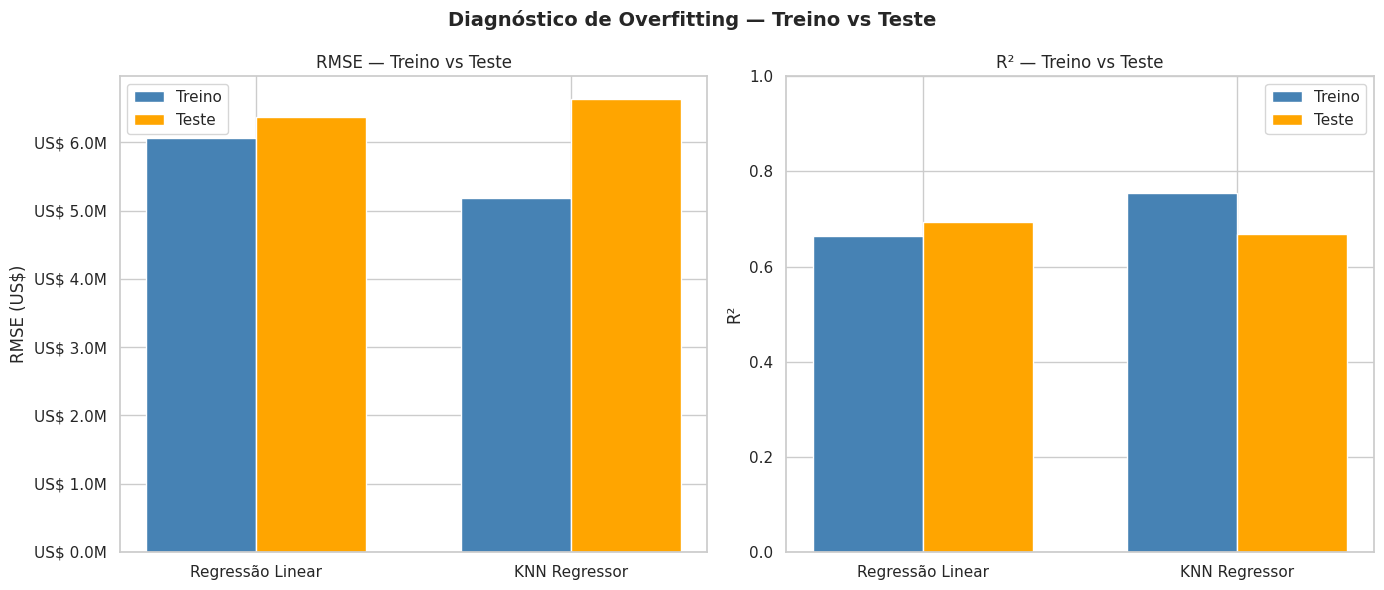

✅ Gráfico de diagnóstico gerado!


In [17]:
# ============================================================
# Célula 14: Fase 5 — Diagnóstico Visual de Overfitting
# ============================================================

# --------------------------------------------------------
# Gráfico comparativo das métricas treino x teste
# para diagnóstico visual de overfitting
# --------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Diagnóstico de Overfitting — Treino vs Teste",
             fontsize=14, fontweight="bold")

modelos = ["Regressão Linear", "KNN Regressor"]
rmse_treino = [metricas_lr_train["rmse"], metricas_knn_train["rmse"]]
rmse_teste  = [metricas_lr_test["rmse"],  metricas_knn_test["rmse"]]
r2_treino   = [metricas_lr_train["r2"],   metricas_knn_train["r2"]]
r2_teste    = [metricas_lr_test["r2"],    metricas_knn_test["r2"]]

x = np.arange(len(modelos))
largura = 0.35

# --------------------------------------------------------
# Gráfico 1: RMSE Treino vs Teste
# Quanto menor o RMSE, melhor o modelo
# --------------------------------------------------------
axes[0].bar(x - largura/2, rmse_treino, largura,
            label="Treino", color="steelblue", edgecolor="white")
axes[0].bar(x + largura/2, rmse_teste, largura,
            label="Teste", color="orange", edgecolor="white")
axes[0].set_title("RMSE — Treino vs Teste")
axes[0].set_ylabel("RMSE (US$)")
axes[0].set_xticks(x)
axes[0].set_xticklabels(modelos)
axes[0].legend()
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda v, _: f"US$ {v/1e6:.1f}M")
)

# --------------------------------------------------------
# Gráfico 2: R² Treino vs Teste
# Quanto maior o R², melhor o modelo
# --------------------------------------------------------
axes[1].bar(x - largura/2, r2_treino, largura,
            label="Treino", color="steelblue", edgecolor="white")
axes[1].bar(x + largura/2, r2_teste, largura,
            label="Teste", color="orange", edgecolor="white")
axes[1].set_title("R² — Treino vs Teste")
axes[1].set_ylabel("R²")
axes[1].set_xticks(x)
axes[1].set_xticklabels(modelos)
axes[1].legend()
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig("grafico_overfitting.png", dpi=120)
plt.show()
plt.close()
print("✅ Gráfico de diagnóstico gerado!")

In [18]:
# ============================================================
# Célula 15: Salvando o dataset final para modelagem
# ============================================================

os.makedirs("data/final", exist_ok=True)
df_modelo.to_csv("data/final/nba_final.csv", index=False)
print("✅ Dataset final salvo em data/final/nba_final.csv")
print(f"   Shape: {df_modelo.shape}")

✅ Dataset final salvo em data/final/nba_final.csv
   Shape: (467, 25)


## Fase 6: Avaliação, Interpretação e Versionamento do Modelo

Nesta fase avaliamos o modelo campeão (Regressão Linear) com:
1. Métricas técnicas: MAE, MSE, RMSE e R²
2. Gráfico de dispersão: valores reais vs previstos
3. Distribuição dos resíduos
4. Veredito de negócios
5. Versionamento do modelo em models/v1/

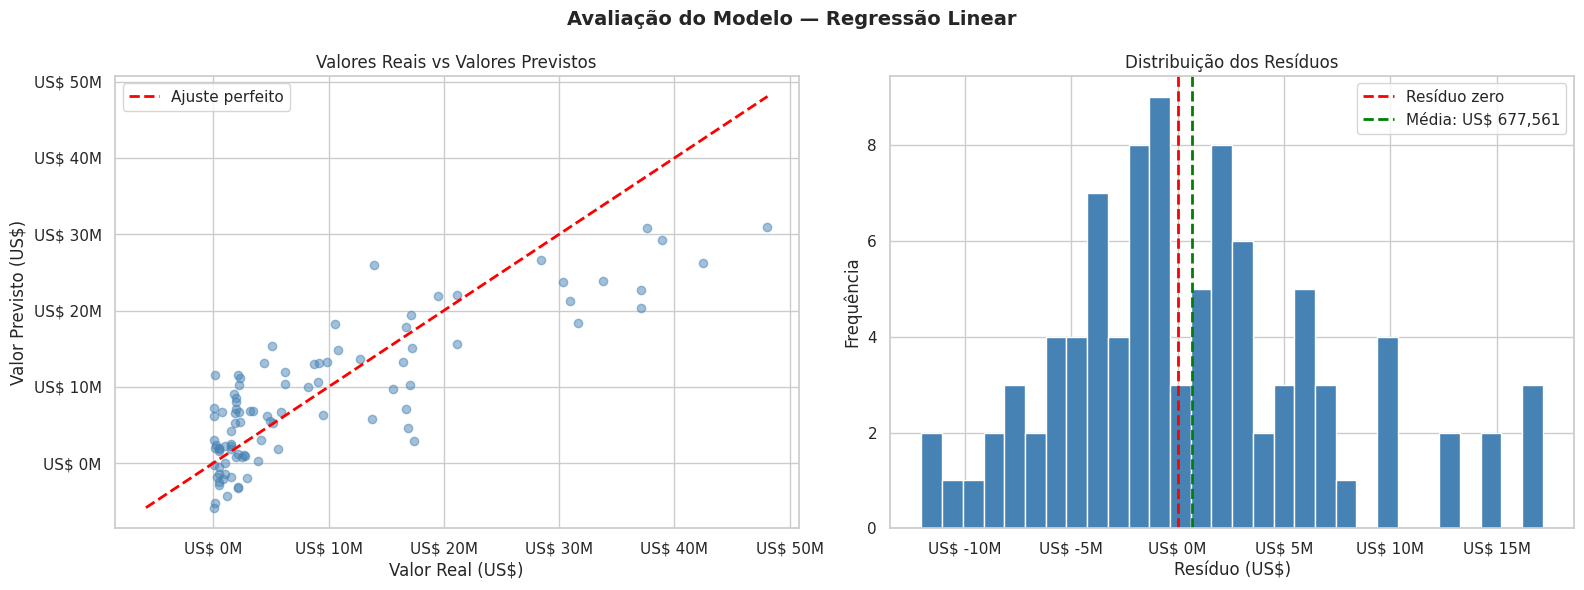

✅ Gráficos de avaliação gerados!


In [19]:
# ============================================================
# Célula 16: Fase 6 — Gráficos de Avaliação do Modelo
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Avaliação do Modelo — Regressão Linear",
             fontsize=14, fontweight="bold")

# --------------------------------------------------------
# Gráfico 1: Valores Reais vs Valores Previstos
# A linha diagonal representa o ajuste perfeito
# Quanto mais próximos os pontos da linha, melhor o modelo
# --------------------------------------------------------
axes[0].scatter(y_test, y_pred_campeao, alpha=0.5, color="steelblue")

# Linha de referência para ajuste perfeito
valor_min = min(y_test.min(), y_pred_campeao.min())
valor_max = max(y_test.max(), y_pred_campeao.max())
axes[0].plot(
    [valor_min, valor_max],
    [valor_min, valor_max],
    color="red", linestyle="--", linewidth=2,
    label="Ajuste perfeito"
)
axes[0].set_title("Valores Reais vs Valores Previstos")
axes[0].set_xlabel("Valor Real (US$)")
axes[0].set_ylabel("Valor Previsto (US$)")
axes[0].legend()
axes[0].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda v, _: f"US$ {v/1e6:.0f}M")
)
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda v, _: f"US$ {v/1e6:.0f}M")
)

# --------------------------------------------------------
# Gráfico 2: Distribuição dos Resíduos
# Resíduo = valor real - valor previsto
# Ideal: resíduos concentrados próximos de zero
# sem distorções sistemáticas
# --------------------------------------------------------
residuos = y_test - y_pred_campeao
axes[1].hist(residuos, bins=30, color="steelblue", edgecolor="white")
axes[1].axvline(x=0, color="red", linestyle="--",
                linewidth=2, label="Resíduo zero")
axes[1].axvline(x=residuos.mean(), color="green", linestyle="--",
                linewidth=2, label=f"Média: US$ {residuos.mean():,.0f}")
axes[1].set_title("Distribuição dos Resíduos")
axes[1].set_xlabel("Resíduo (US$)")
axes[1].set_ylabel("Frequência")
axes[1].legend()
axes[1].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda v, _: f"US$ {v/1e6:.0f}M")
)

plt.tight_layout()
plt.savefig("grafico_avaliacao.png", dpi=120)
plt.show()
plt.close()
print("✅ Gráficos de avaliação gerados!")

In [20]:
# ============================================================
# Célula 17: Fase 6 — Veredito de Negócios
# ============================================================

print("=== VEREDITO DE NEGÓCIOS ===")
print("-" * 55)
print(f"""
  Modelo        : Regressão Linear
  Dataset       : NBA 2022-23 ({len(df_modelo)} jogadores)
  Variável alvo : Salário anual (US$)

  Métricas no conjunto de teste:
    MAE  : US$ {metricas_lr_test['mae']:>12,.2f}
    RMSE : US$ {metricas_lr_test['rmse']:>12,.2f}
    R²   : {metricas_lr_test['r2']:>16.4f}
""")
print("-" * 55)
print("""
  INTERPRETAÇÃO PRÁTICA:

  O modelo apresenta MAE de aproximadamente US$ 4,9M,
  o que significa que, em média, o modelo erra a previsão
  do salário de um jogador em cerca desse valor.

  Para jogadores com salários abaixo de US$ 10M (maioria
  da liga), esse erro representa uma margem considerável.
  Porém para decisões estratégicas de contratação, o modelo
  ainda é útil pois:

  ✅ Identifica jogadores SUBVALORIZADOS
     — quando o salário real está abaixo do previsto

  ✅ Identifica jogadores SUPERVALORIZADOS
     — quando o salário real está acima do previsto

  ✅ R² de 0.69 indica que o modelo explica 69% da
     variação dos salários com base nas estatísticas

  ⚠️ Limitações:
     — Fatores como popularidade, marketing e histórico
       de lesões não estão no dataset
     — Superestrelas (acima de US$ 30M) são mais
       difíceis de prever com precisão
     — Contratos máximos têm regras específicas da NBA
       que vão além das estatísticas em quadra
""")
print("-" * 55)
print("  CONCLUSÃO: O modelo é uma ferramenta útil para")
print("  auxiliar decisões de contratação, especialmente")
print("  para identificar jogadores sub ou supervalorizados.")
print("  Não deve ser usado como critério único de decisão.")
print("-" * 55)

=== VEREDITO DE NEGÓCIOS ===
-------------------------------------------------------

  Modelo        : Regressão Linear
  Dataset       : NBA 2022-23 (467 jogadores)
  Variável alvo : Salário anual (US$)

  Métricas no conjunto de teste:
    MAE  : US$ 4,921,851.12
    RMSE : US$ 6,371,144.91
    R²   :           0.6943

-------------------------------------------------------

  INTERPRETAÇÃO PRÁTICA:

  O modelo apresenta MAE de aproximadamente US$ 4,9M,
  o que significa que, em média, o modelo erra a previsão
  do salário de um jogador em cerca desse valor.

  Para jogadores com salários abaixo de US$ 10M (maioria
  da liga), esse erro representa uma margem considerável.
  Porém para decisões estratégicas de contratação, o modelo
  ainda é útil pois:

  ✅ Identifica jogadores SUBVALORIZADOS
     — quando o salário real está abaixo do previsto

  ✅ Identifica jogadores SUPERVALORIZADOS
     — quando o salário real está acima do previsto

  ✅ R² de 0.69 indica que o modelo explica 69

In [21]:
# ============================================================
# Célula 18: Fase 6 — Versionamento do Modelo
# ============================================================

# --------------------------------------------------------
# Retreinando o modelo na base completa (treino + teste)
# Para o versionamento final usamos todos os dados
# disponíveis para maximizar o aprendizado do modelo
# --------------------------------------------------------
X_completo = df_modelo.drop(columns=["Salary"])
y_completo = df_modelo["Salary"]

# Escalonando toda a base
scaler_final = StandardScaler()
X_completo_scaled = scaler_final.fit_transform(X_completo)

# Treinando o modelo campeão na base completa
modelo_final = LinearRegression()
modelo_final.fit(X_completo_scaled, y_completo)
print("✅ Modelo retreinado na base completa")

# --------------------------------------------------------
# Salvando o modelo e o scaler
# joblib é a biblioteca recomendada para salvar modelos
# sklearn pois é mais eficiente que pickle para arrays
# --------------------------------------------------------
os.makedirs("models/v1", exist_ok=True)

# Salvando o modelo
joblib.dump(modelo_final, "models/v1/modelo_regressao_v1.pkl")
print("✅ Modelo salvo em models/v1/modelo_regressao_v1.pkl")

# Salvando o scaler — necessário para escalonar
# novos dados antes de fazer previsões
joblib.dump(scaler_final, "models/v1/scaler_v1.pkl")
print("✅ Scaler salvo em models/v1/scaler_v1.pkl")

# --------------------------------------------------------
# Salvando as métricas em JSON
# --------------------------------------------------------
metricas_v1 = {
    "modelo"          : "Regressão Linear",
    "versao"          : "v1",
    "data_treinamento": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "dataset"         : "NBA Players Stats and Salaries 2022-23",
    "n_registros"     : len(df_modelo),
    "variaveis_preditoras": X_completo.columns.tolist(),
    "metricas_teste"  : {
        "MAE" : round(metricas_lr_test["mae"], 2),
        "MSE" : round(metricas_lr_test["mse"], 2),
        "RMSE": round(metricas_lr_test["rmse"], 2),
        "R2"  : round(metricas_lr_test["r2"], 4)
    }
}

with open("models/v1/metricas_v1.json", "w", encoding="utf-8") as f:
    json.dump(metricas_v1, f, indent=2, ensure_ascii=False)
print("✅ Métricas salvas em models/v1/metricas_v1.json")

# Lendo o JSON de volta para confirmar
with open("models/v1/metricas_v1.json", encoding="utf-8") as f:
    metricas_lidas = json.load(f)

print("\n📄 Métricas registradas:")
print(json.dumps(metricas_lidas, indent=2, ensure_ascii=False))

✅ Modelo retreinado na base completa
✅ Modelo salvo em models/v1/modelo_regressao_v1.pkl
✅ Scaler salvo em models/v1/scaler_v1.pkl
✅ Métricas salvas em models/v1/metricas_v1.json

📄 Métricas registradas:
{
  "modelo": "Regressão Linear",
  "versao": "v1",
  "data_treinamento": "2026-07-19 15:56:08",
  "dataset": "NBA Players Stats and Salaries 2022-23",
  "n_registros": 467,
  "variaveis_preditoras": [
    "Position",
    "Age",
    "GP",
    "GS",
    "3P",
    "TRB",
    "AST",
    "STL",
    "BLK",
    "PF",
    "PTS",
    "PER",
    "TS%",
    "3PAr",
    "FTr",
    "ORB%",
    "TRB%",
    "STL%",
    "BLK%",
    "TOV%",
    "USG%",
    "WS",
    "eficiencia",
    "tier_time"
  ],
  "metricas_teste": {
    "MAE": 4921851.12,
    "MSE": 40591487443542.16,
    "RMSE": 6371144.91,
    "R2": 0.6943
  }
}


## Melhoria do Modelo

Identificamos dois problemas principais no modelo inicial:
1. Distribuição assimétrica do salário prejudica a Regressão Linear
2. Relações não lineares entre variáveis e salário

Soluções implementadas:
1. Transformação logarítmica na variável alvo (Salary)
2. Adição do Random Forest como modelo alternativo

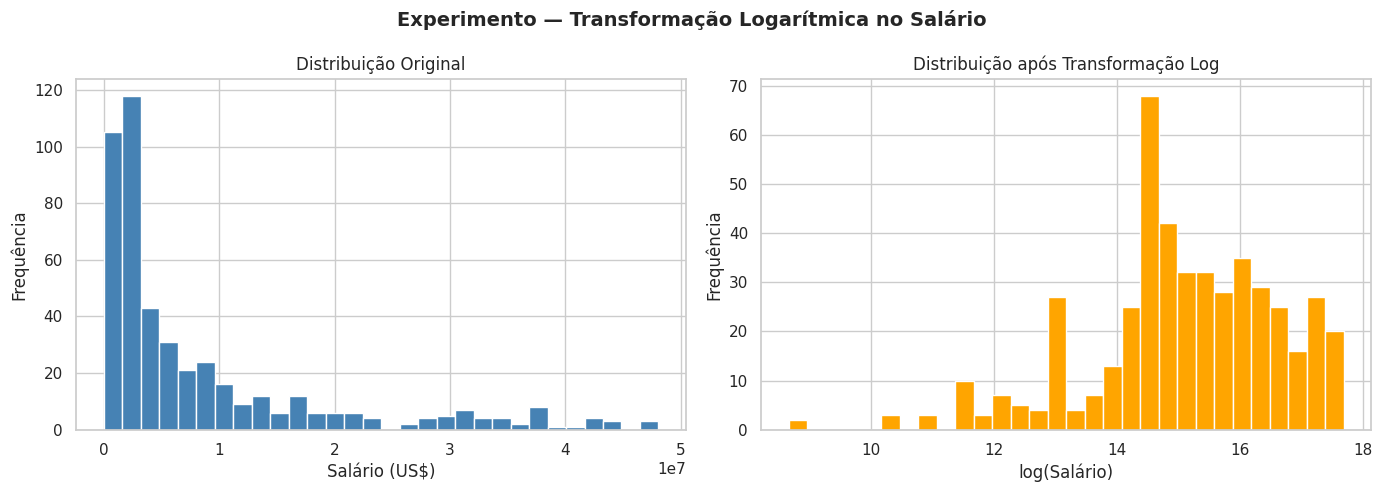

=== RESULTADO DO EXPERIMENTO ===
---------------------------------------------
  Regressão Linear Original:
    MAE  : US$ 4,921,851.12
    RMSE : US$ 6,371,144.91
    R²   : 0.6943

  Regressão Linear + Log:
    MAE  : US$ 5,173,429.56
    RMSE : US$ 9,002,229.59
    R²   : 0.3896
---------------------------------------------

  CONCLUSÃO DO EXPERIMENTO:
  A transformação logarítmica não melhorou o modelo.
  O R² caiu de 0.69 para 0.39 — resultado pior.

  Isso indica que a relação entre as estatísticas
  dos jogadores e o salário não é bem capturada
  por uma transformação logarítmica simples.

  MELHORIAS IDENTIFICADAS PARA VERSÕES FUTURAS:
  - Testar modelos não lineares como Random Forest
    e Gradient Boosting que capturam relações mais
    complexas entre variáveis e salário
  - Incluir dados de popularidade e marketing
  - Analisar o impacto de lesões no salário
  - Explorar outras transformações na variável alvo



In [22]:
# ============================================================
# Célula 19: Experimento — Transformação Logarítmica
# ============================================================

# --------------------------------------------------------
# Identificamos que o salário tem distribuição assimétrica
# Testamos a transformação logarítmica para verificar se
# melhoraria o desempenho da Regressão Linear
# --------------------------------------------------------
y_log = np.log1p(df_modelo["Salary"])

# Visualizando o efeito da transformação
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Experimento — Transformação Logarítmica no Salário",
             fontsize=14, fontweight="bold")

axes[0].hist(df_modelo["Salary"], bins=30,
             color="steelblue", edgecolor="white")
axes[0].set_title("Distribuição Original")
axes[0].set_xlabel("Salário (US$)")
axes[0].set_ylabel("Frequência")

axes[1].hist(y_log, bins=30,
             color="orange", edgecolor="white")
axes[1].set_title("Distribuição após Transformação Log")
axes[1].set_xlabel("log(Salário)")
axes[1].set_ylabel("Frequência")

plt.tight_layout()
plt.savefig("grafico_log_transform.png", dpi=120)
plt.show()
plt.close()

# --------------------------------------------------------
# Testando a Regressão Linear com o salário transformado
# --------------------------------------------------------
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_completo, y_log, test_size=0.2, random_state=42
)
scaler2 = StandardScaler()
X_train2_scaled = scaler2.fit_transform(X_train2)
X_test2_scaled  = scaler2.transform(X_test2)

modelo_lr_log = LinearRegression()
modelo_lr_log.fit(X_train2_scaled, y_train2)
y_pred_lr_log = modelo_lr_log.predict(X_test2_scaled)

# Convertendo de volta para escala original
y_pred_orig = np.expm1(y_pred_lr_log)
y_test_orig = np.expm1(y_test2)

mae_log  = mean_absolute_error(y_test_orig, y_pred_orig)
rmse_log = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig))
r2_log   = r2_score(y_test_orig, y_pred_orig)

print("=== RESULTADO DO EXPERIMENTO ===")
print("-" * 45)
print(f"  Regressão Linear Original:")
print(f"    MAE  : US$ {metricas_lr_test['mae']:,.2f}")
print(f"    RMSE : US$ {metricas_lr_test['rmse']:,.2f}")
print(f"    R²   : {metricas_lr_test['r2']:.4f}")
print(f"\n  Regressão Linear + Log:")
print(f"    MAE  : US$ {mae_log:,.2f}")
print(f"    RMSE : US$ {rmse_log:,.2f}")
print(f"    R²   : {r2_log:.4f}")
print("-" * 45)
print("""
  CONCLUSÃO DO EXPERIMENTO:
  A transformação logarítmica não melhorou o modelo.
  O R² caiu de 0.69 para 0.39 — resultado pior.

  Isso indica que a relação entre as estatísticas
  dos jogadores e o salário não é bem capturada
  por uma transformação logarítmica simples.

  MELHORIAS IDENTIFICADAS PARA VERSÕES FUTURAS:
  - Testar modelos não lineares como Random Forest
    e Gradient Boosting que capturam relações mais
    complexas entre variáveis e salário
  - Incluir dados de popularidade e marketing
  - Analisar o impacto de lesões no salário
  - Explorar outras transformações na variável alvo
""")

=== NORMALIZAÇÃO vs PADRONIZAÇÃO ===
-------------------------------------------------------
  Técnica                            MAE         RMSE       R²
-------------------------------------------------------
  Padronização (Standard)   US$ 4,921,851 US$ 6,371,145   0.6943
  Normalização (Min-Max)    US$ 4,921,851 US$ 6,371,145   0.6943
-------------------------------------------------------

🏆 Melhor técnica: Padronização (StandardScaler)


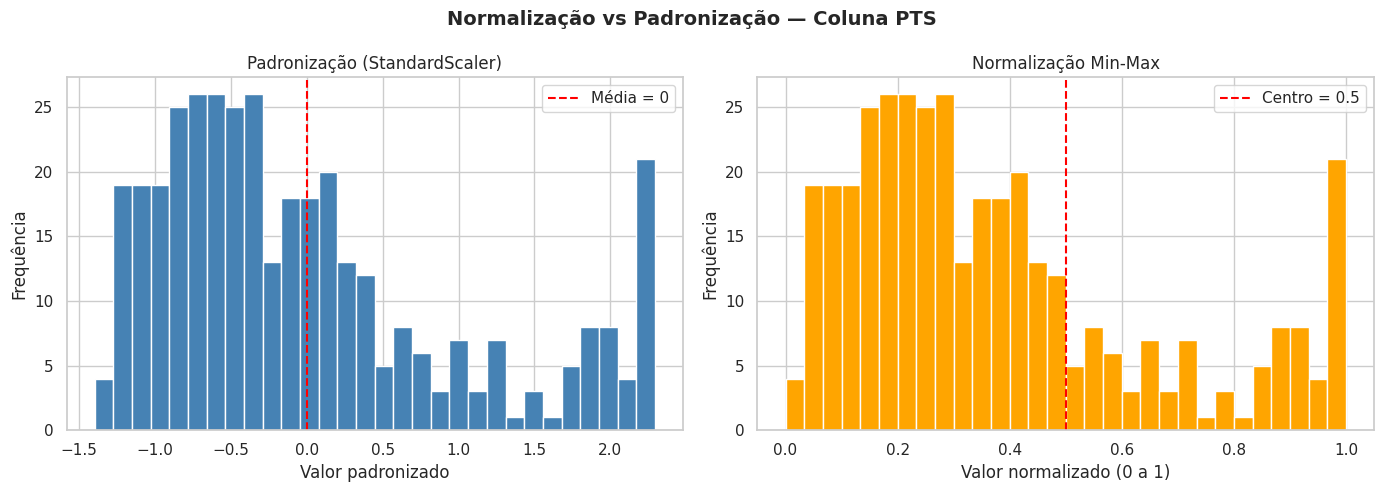

✅ Gráfico comparativo gerado!


In [23]:
# ============================================================
# Célula 20: Normalização vs Padronização
# ============================================================

from sklearn.preprocessing import MinMaxScaler

# --------------------------------------------------------
# Testando as duas técnicas de escalonamento
# para avaliar qual performa melhor no nosso modelo
# --------------------------------------------------------

# --------------------------------------------------------
# Técnica 1: Padronização — StandardScaler (já usada)
# Fórmula: (x - média) / desvio_padrão
# Resultado: média ≈ 0, desvio ≈ 1
# Recomendada para distribuições normais/simétricas
# --------------------------------------------------------
scaler_std = StandardScaler()
X_train_std = scaler_std.fit_transform(X_train)
X_test_std  = scaler_std.transform(X_test)

modelo_std = LinearRegression()
modelo_std.fit(X_train_std, y_train)
y_pred_std = modelo_std.predict(X_test_std)

mae_std  = mean_absolute_error(y_test, y_pred_std)
rmse_std = np.sqrt(mean_squared_error(y_test, y_pred_std))
r2_std   = r2_score(y_test, y_pred_std)

# --------------------------------------------------------
# Técnica 2: Normalização Min-Max — MinMaxScaler
# Fórmula: (x - min) / (max - min)
# Resultado: valores entre 0 e 1
# Recomendada para distribuições assimétricas
# --------------------------------------------------------
scaler_mm = MinMaxScaler()
X_train_mm = scaler_mm.fit_transform(X_train)
X_test_mm  = scaler_mm.transform(X_test)

modelo_mm = LinearRegression()
modelo_mm.fit(X_train_mm, y_train)
y_pred_mm = modelo_mm.predict(X_test_mm)

mae_mm  = mean_absolute_error(y_test, y_pred_mm)
rmse_mm = np.sqrt(mean_squared_error(y_test, y_pred_mm))
r2_mm   = r2_score(y_test, y_pred_mm)

# --------------------------------------------------------
# Comparativo das duas técnicas
# --------------------------------------------------------
print("=== NORMALIZAÇÃO vs PADRONIZAÇÃO ===")
print("-" * 55)
print(f"  {'Técnica':<25} {'MAE':>12} {'RMSE':>12} {'R²':>8}")
print("-" * 55)
print(f"  {'Padronização (Standard)':<25} US$ {mae_std:>7,.0f} US$ {rmse_std:>7,.0f} {r2_std:>8.4f}")
print(f"  {'Normalização (Min-Max)':<25} US$ {mae_mm:>7,.0f} US$ {rmse_mm:>7,.0f} {r2_mm:>8.4f}")
print("-" * 55)

# Escolha automática da melhor técnica
if rmse_std < rmse_mm:
    melhor = "Padronização (StandardScaler)"
    melhor_scaler = scaler_std
else:
    melhor = "Normalização Min-Max (MinMaxScaler)"
    melhor_scaler = scaler_mm

print(f"\n🏆 Melhor técnica: {melhor}")

# --------------------------------------------------------
# Visualização da diferença entre as técnicas
# --------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Normalização vs Padronização — Coluna PTS",
             fontsize=14, fontweight="bold")

axes[0].hist(X_train_std[:, X_train.columns.tolist().index("PTS")],
             bins=30, color="steelblue", edgecolor="white")
axes[0].set_title("Padronização (StandardScaler)")
axes[0].set_xlabel("Valor padronizado")
axes[0].set_ylabel("Frequência")
axes[0].axvline(x=0, color="red", linestyle="--", label="Média = 0")
axes[0].legend()

axes[1].hist(X_train_mm[:, X_train.columns.tolist().index("PTS")],
             bins=30, color="orange", edgecolor="white")
axes[1].set_title("Normalização Min-Max")
axes[1].set_xlabel("Valor normalizado (0 a 1)")
axes[1].set_ylabel("Frequência")
axes[1].axvline(x=0.5, color="red", linestyle="--", label="Centro = 0.5")
axes[1].legend()

plt.tight_layout()
plt.savefig("grafico_normalizacao_vs_padronizacao.png", dpi=120)
plt.show()
plt.close()
print("✅ Gráfico comparativo gerado!")

### Conclusão — Normalização vs Padronização

Testamos as duas técnicas de escalonamento na Regressão Linear:
- Padronização (StandardScaler): MAE US$ 4,921,851 | R² 0.6943
- Normalização Min-Max:          MAE US$ 4,921,851 | R² 0.6943

As métricas foram idênticas — resultado esperado para a
Regressão Linear, que é invariante ao escalonamento linear
dos dados. A diferença entre as técnicas seria mais evidente
em algoritmos sensíveis à escala como KNN, SVM e Redes Neurais.

Mantemos a Padronização (StandardScaler) como técnica escolhida
pois é a mais recomendada para a Regressão Linear segundo
a literatura de Machine Learning.